## 7.5 결합 클러스터(CCSD): 후-하트리-폭 방법

In [1]:
# 라이브러리 임포트
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms.optimizers import COBYLA
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# H2 분자 해밀토니안을 직접 정의 (모든 항이 2큐비트에 작용)
pauli_dict = {
    "XX": -0.5,   # 큐비트 0,1에 작용하는 XX
    "YY": -0.5,   # 큐비트 0,1에 작용하는 YY
    "ZZ": 0.6,    # 큐비트 0,1에 작용하는 ZZ
    "II": -1.0    # 항등 연산자
}

In [3]:
# SparsePauliOp로 해밀토니안 구성
hamiltonian = SparsePauliOp.from_list([(key, value) for key, value in pauli_dict.items()])

In [4]:
# UCCSD 근사를 위한 EfficientSU2 양자회로 초기화
num_qubits = 2
ansatz = EfficientSU2(num_qubits, reps=2)

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_6/2500620650.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits, reps=2)


In [5]:
# COBYLA 최적화기로 VQE 알고리즘 설정
optimizer = COBYLA(maxiter=200)
backend = AerSimulator()

In [6]:
# VQE 알고리즘에 필요한 Estimator 프리미티브 설정
estimator = StatevectorEstimator()  # 호환성 수정: V2 추정기

In [7]:
# Estimator를 사용해 VQE 알고리즘 설정
vqe = VQE(estimator, ansatz, optimizer)

In [8]:
# VQE 실행으로 최소 고유값(바닥상태 에너지) 탐색
result = vqe.compute_minimum_eigenvalue(hamiltonian)
print(f"바닥상태 에너지: {result.eigenvalue.real}")

바닥상태 에너지: -2.599996890791096


In [9]:
# Aer 시뮬레이터용으로 양자회로 트랜스파일
qc = transpile(ansatz, backend)

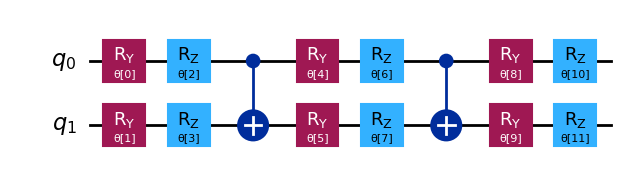

In [10]:
# 회로 그리기
qc.draw(output='mpl')
plt.show()